<a href="https://colab.research.google.com/github/LuisTT0903/Processamento-de-Sinais1/blob/main/Pratica3Quest%C3%A3o4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

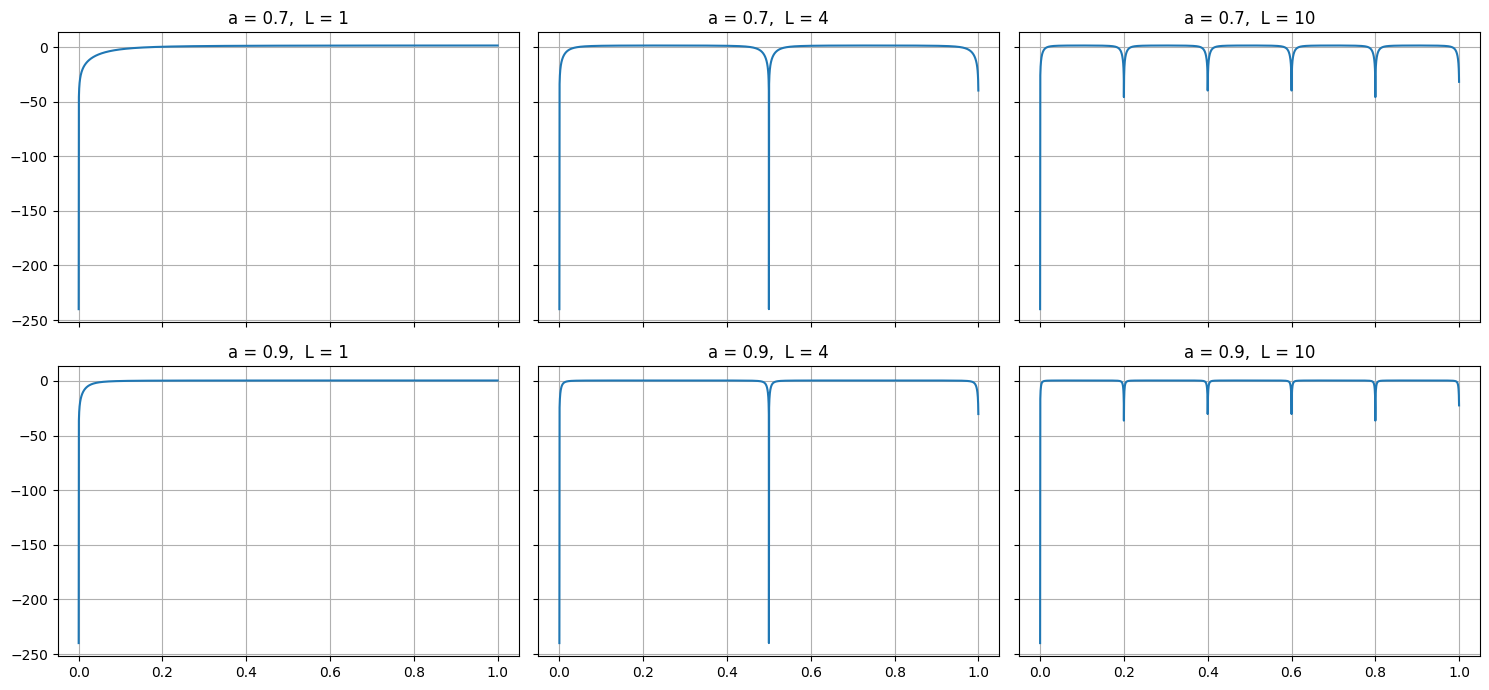

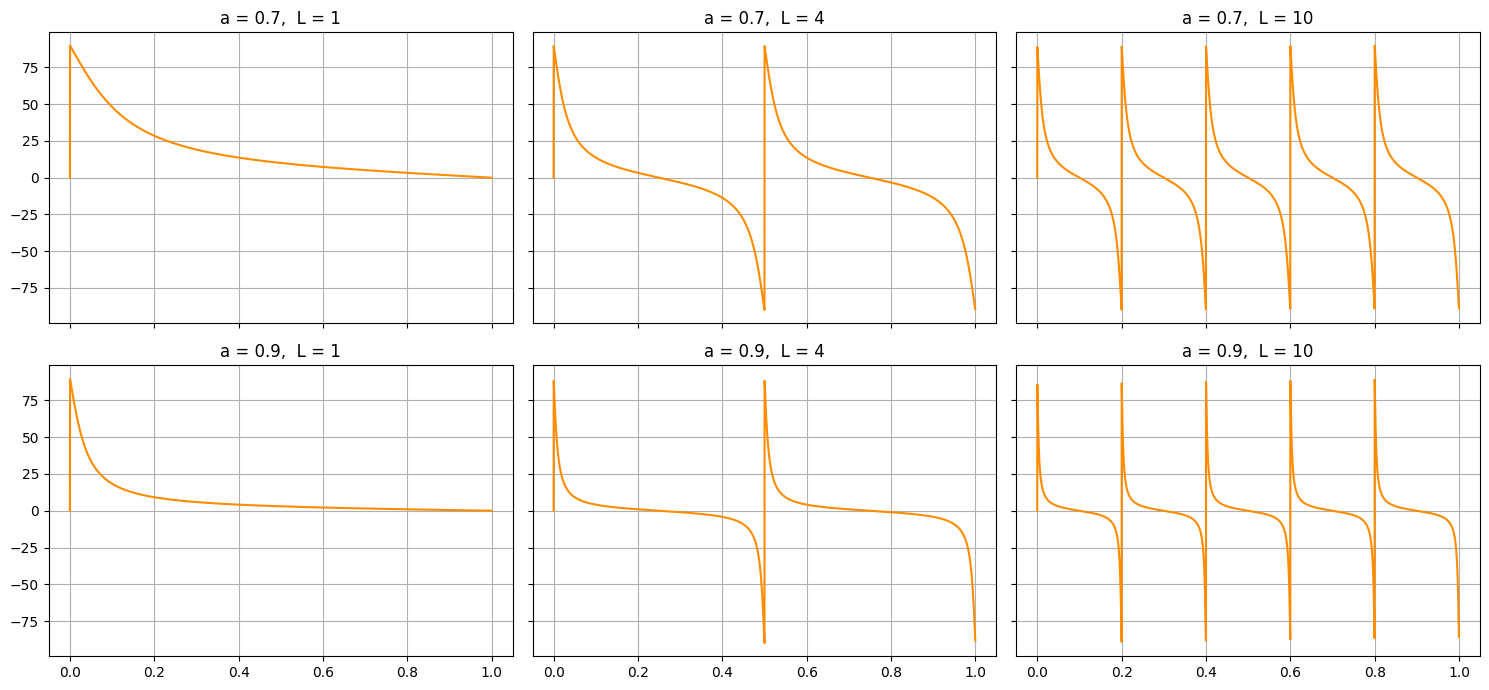

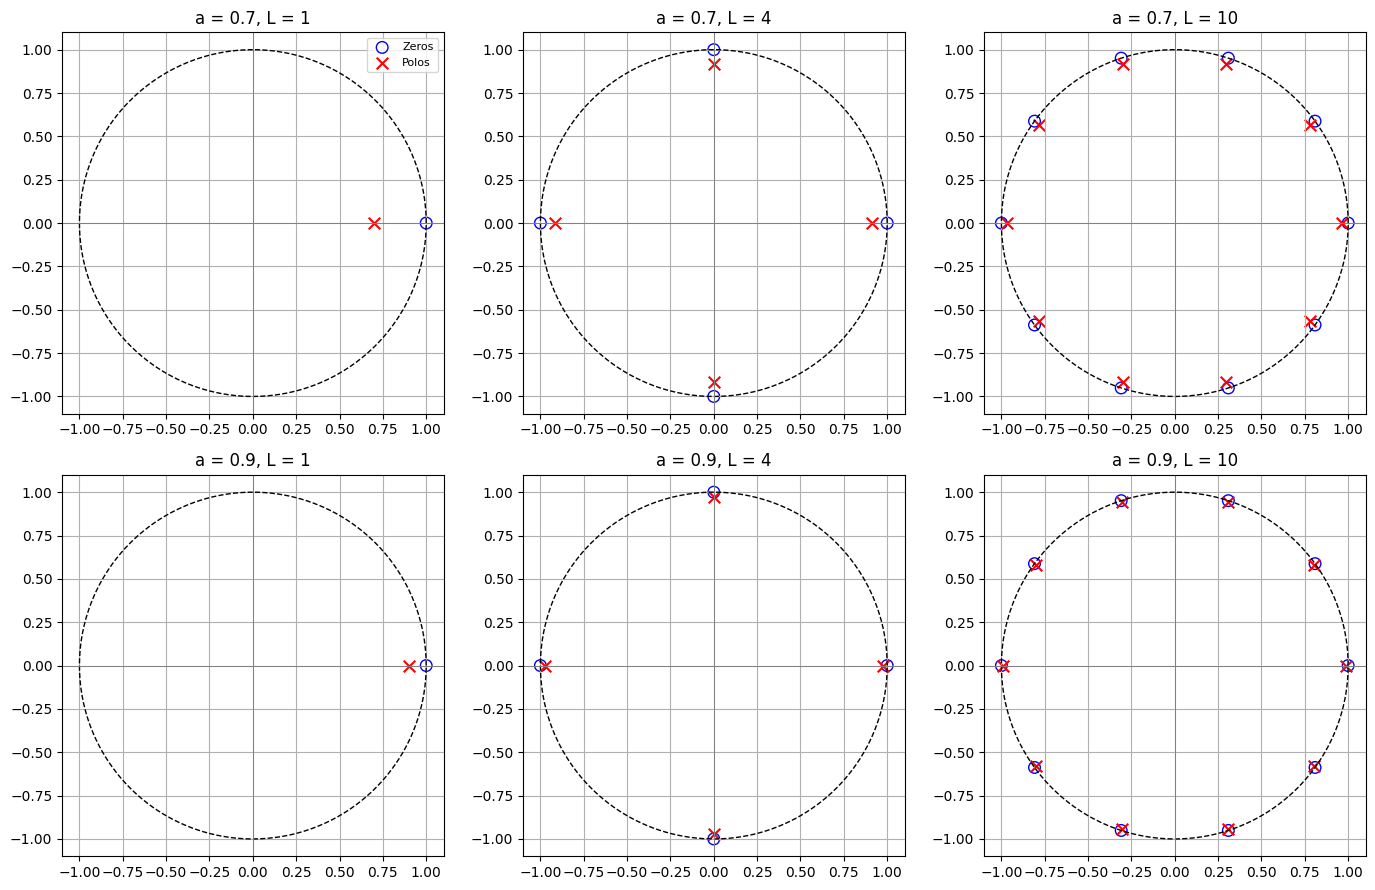

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

valores_a = [0.7, 0.9]
valores_L = [1, 4, 10]

def coeficientes(a, L):
    """Monta b e a_coef de H(z) = (1 - z^-L)/(1 - a z^-L)."""
    b = np.zeros(L + 1); b[0] = 1; b[L] = -1
    a_coef = np.zeros(L + 1); a_coef[0] = 1; a_coef[L] = -a
    return b, a_coef

# --- Módulo, para as 6 combinações ---
fig, axes = plt.subplots(len(valores_a), len(valores_L), figsize=(15, 7), sharex=True, sharey=True)
for i, a in enumerate(valores_a):
    for j, L in enumerate(valores_L):
        b, a_coef = coeficientes(a, L)
        w, H = signal.freqz(b, a_coef, worN=4096)
        mod_dB = 20 * np.log10(np.abs(H) + 1e-12)
        ax = axes[i, j]
        ax.plot(w / np.pi, mod_dB, linewidth=1.5)
        ax.set_title(f"a = {a},  L = {L}"); ax.grid(True)
plt.tight_layout(); plt.show()

# --- Fase, para as 6 combinações ---
fig, axes = plt.subplots(len(valores_a), len(valores_L), figsize=(15, 7), sharex=True, sharey=True)
for i, a in enumerate(valores_a):
    for j, L in enumerate(valores_L):
        b, a_coef = coeficientes(a, L)
        w, H = signal.freqz(b, a_coef, worN=4096)
        fase = np.degrees(np.angle(H))
        ax = axes[i, j]
        ax.plot(w / np.pi, fase, linewidth=1.5, color="darkorange")
        ax.set_title(f"a = {a},  L = {L}"); ax.grid(True)
plt.tight_layout(); plt.show()

# --- Polos e zeros, para as 6 combinações ---
def plota_pz_no_eixo(ax, zeros, polos, titulo):
    theta = np.linspace(0, 2*np.pi, 512)
    ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=1)
    ax.axhline(0, color='gray', linewidth=0.7); ax.axvline(0, color='gray', linewidth=0.7)
    ax.scatter(zeros.real, zeros.imag, marker='o', s=70, facecolors='none', edgecolors='b', label='Zeros')
    ax.scatter(polos.real, polos.imag, marker='x', s=70, color='r', label='Polos')
    ax.set_title(titulo); ax.set_aspect('equal'); ax.grid(True)

fig, axes = plt.subplots(len(valores_a), len(valores_L), figsize=(14, 9))
for i, a in enumerate(valores_a):
    for j, L in enumerate(valores_L):
        b, a_coef = coeficientes(a, L)
        zeros, polos, k = signal.tf2zpk(b, a_coef)
        plota_pz_no_eixo(axes[i, j], zeros, polos, f"a = {a}, L = {L}")
axes[0,0].legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

Comentário dos resultados

Módulo. Os seis gráficos confirmam exatamente a relação teórica
𝐻
𝐿
(
𝑒
𝑗
𝜔
)
=
𝐻
1
(
𝑒
𝑗
𝐿
𝜔
)
H
L
	​

(e
jω
)=H
1
	​

(e
jLω
): o padrão do caso
𝐿
=
1
L=1 (um único mergulho profundo perto de
𝜔
=
0
ω=0, subindo suavemente até um patamar perto de
𝜔
=
𝜋
ω=π) aparece repetido 4 vezes para
𝐿
=
4
L=4 (mergulhos em
𝜔
=
0
ω=0,
0,5
𝜋
0,5π e
𝜋
π — na verdade contando a repetição completa seriam 4 mergulhos por período de
2
𝜋
2π, e o gráfico mostra meio período, de 0 a
𝜋
π, por isso aparecem 2 nesse intervalo mostrado) e 10 vezes para
𝐿
=
10
L=10 (5 mergulhos visíveis entre 0 e
𝜋
π). O valor de pico (próximo de 0 dB, mas ligeiramente acima) é idêntico nos três valores de
𝐿
L para um mesmo
𝑎
a — por volta de +1,4 dB para
𝑎
=
0,7
a=0,7 e +0,45 dB para
𝑎
=
0,9
a=0,9 — confirmando que
𝐿
L só multiplica quantos "dentes" cabem no intervalo, sem alterar a profundidade/altura de cada um. Já o fundo de cada entalhe cai a praticamente
−
240
−240 dB nos seis casos: numericamente esse valor é só o piso artificial que usamos (
10
−
12
10
−12
 dentro do logaritmo) — na prática, ali a resposta é exatamente zero, porque cada entalhe está exatamente sobre um zero de
𝐻
(
𝑧
)
H(z), que fica em cima do círculo unitário.

Fase. O padrão em dente de serra também se repete de forma consistente com a mesma relação
𝐻
𝐿
(
𝑒
𝑗
𝜔
)
=
𝐻
1
(
𝑒
𝑗
𝐿
𝜔
)
H
L
	​

(e
jω
)=H
1
	​

(e
jLω
): cada entalhe do módulo tem, na fase, uma subida rápida seguida de uma queda abrupta de quase 180°, típica da passagem por um zero exatamente sobre o círculo unitário. Para
𝐿
=
4
L=4 e
𝐿
=
10
L=10 esse mesmo salto se repete a cada
2
𝜋
/
𝐿
2π/L, de forma idêntica em forma e amplitude ao que acontece uma única vez no caso
𝐿
=
1
L=1 — só comprimido no eixo de frequência.

Diagrama de polos e zeros. Os zeros (círculos azuis) caem exatamente sobre o círculo unitário, nos
𝐿
L ângulos igualmente espaçados esperados (para
𝐿
=
4
L=4: 0°, 90°, 180°, 270°; para
𝐿
=
10
L=10: múltiplos de 36°). Os polos (x vermelhos) aparecem sempre no mesmo ângulo de cada zero, mas puxados para dentro do círculo — e fica bem visível, comparando as duas linhas do gráfico, que para
𝑎
=
0,9
a=0,9 os polos ficam visivelmente mais colados aos zeros (quase sobrepostos, sobretudo para
𝐿
=
10
L=10) do que para
𝑎
=
0,7
a=0,7, onde a separação radial entre polo e zero é claramente maior. Isso é a representação geométrica direta do raio
𝑎
1
/
𝐿
a
1/L
: quanto mais perto de 1 (maior
𝑎
a ou maior
𝐿
L), mais próximo o polo fica do zero correspondente — e é exatamente essa proximidade que faz os entalhes de
𝑎
=
0,9
a=0,9 parecerem mais finos/abruptos no gráfico de módulo, apesar do pico de ganho ser menor que o de
𝑎
=
0,7
a=0,7.

Síntese. Os três conjuntos de gráficos (módulo, fase e polos/zeros) contam a mesma história sob três ângulos diferentes:
𝐿
L define quantas vezes o padrão básico (de
𝐿
=
1
L=1) se repete ao redor do círculo unitário — ou seja, quantos zeros/polos existem e o espaçamento angular entre eles — enquanto
𝑎
a define o quão perto cada polo fica do zero correspondente, controlando a nitidez (largura) de cada entalhe sem alterar seu pico de ganho. Isso é exatamente o comportamento esperado de um filtro pente IIR:
𝐿
L ajusta o número de "dentes" por volta completa, e
𝑎
a ajusta a resolução/afiação de cada um deles.